<a href="https://colab.research.google.com/github/defneulku-hub/DSA210-project-Irmak-Defne-lk-/blob/main/dsa210_eda_hyp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Summary of the Data ---
       Retail_price_TL  Infill_density_%   Ship_days
count        100.00000        100.000000  100.000000
mean         300.35740         54.800000    2.620000
std          315.79371         29.214636    4.007014
min            8.50000         10.000000    1.000000
25%          129.99000         40.000000    2.000000
50%          200.00000         70.000000    2.000000
75%          352.00000         90.000000    3.000000
max         2300.00000         90.000000   30.000000


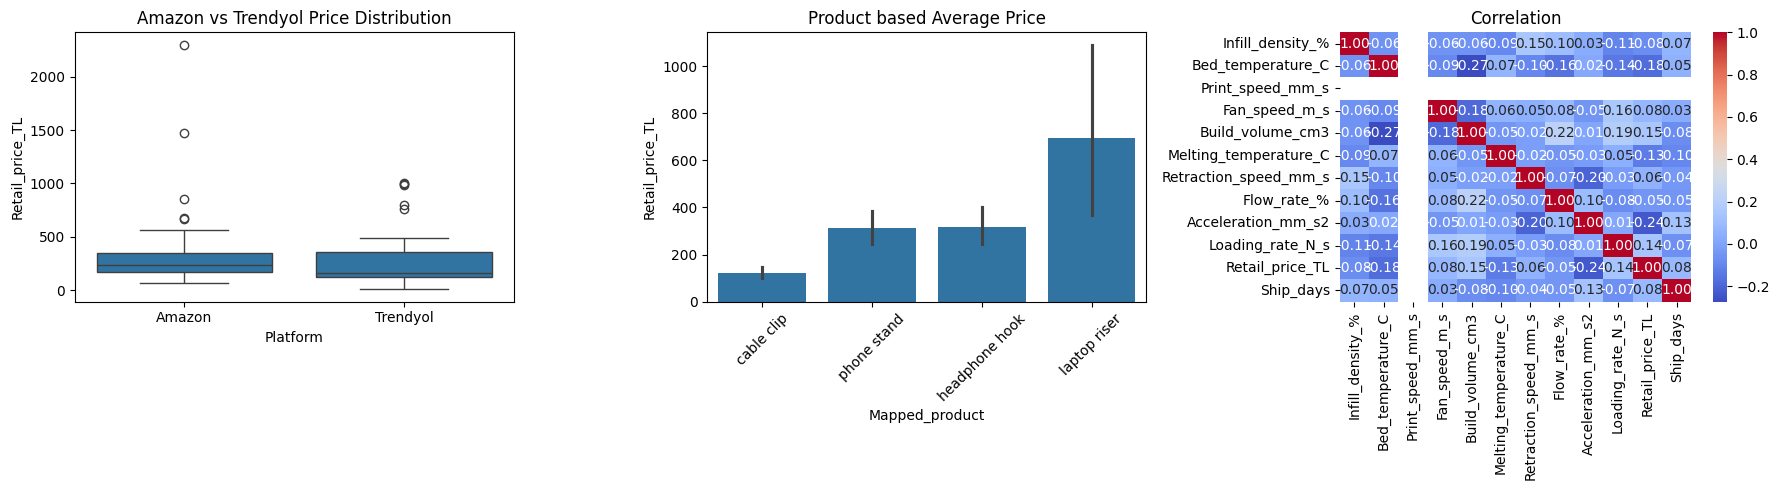


--- Results of Hypothesis Testing ---
P-Value: 0.3269
Result: There is no statistically significant difference between the platforms.

--- Regression Analysis ---


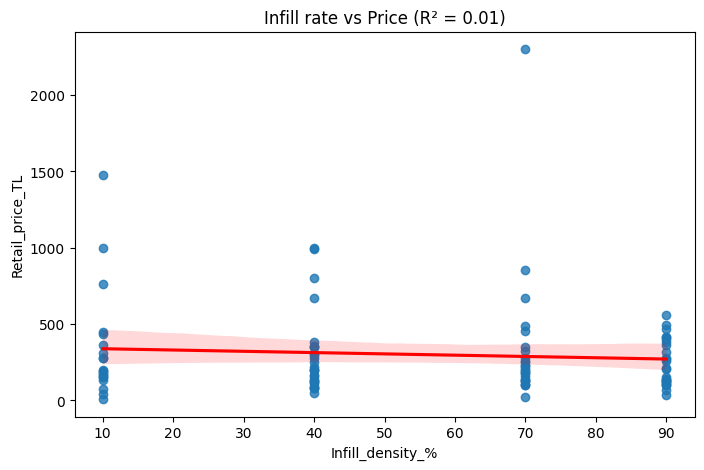

Model Score (R2): 0.0061


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings

#without this it gives me warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('FDM_enrichment_Dataset.csv')

df['Retail_price_TL'] = df['Retail_price_TL'].str.replace(',', '.')
df['Retail_price_TL'] = df['Retail_price_TL'].astype(float)

#recit1
df_clean = df.dropna(subset=['Retail_price_TL', 'Platform'])

# EDA recit2
print("--- Summary of the Data ---")
print(df_clean[['Retail_price_TL', 'Infill_density_%', 'Ship_days']].describe())

plt.figure(figsize=(18, 5))

# Graph 1: Platform comparison (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(x='Platform', y='Retail_price_TL', data=df_clean)
plt.title('Amazon vs Trendyol Price Distribution')

# Graph 2: product type (Barplot)
plt.subplot(1, 3, 2)
sns.barplot(x='Mapped_product', y='Retail_price_TL', data=df_clean)
plt.xticks(rotation=45)
plt.title('Product based Average Price')

# Graph 3: Correlation Heatmap - Recit 2
plt.subplot(1, 3, 3)
# only numerical columns
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation')

plt.tight_layout()
plt.show()

# Hyp testing recit 4
print("\n--- Results of Hypothesis Testing ---")
amazon_prices = df_clean[df_clean['Platform'] == 'Amazon']['Retail_price_TL']
trendyol_prices = df_clean[df_clean['Platform'] == 'Trendyol']['Retail_price_TL']

t_stat, p_val = stats.ttest_ind(amazon_prices, trendyol_prices)
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: A statistically significant difference exists between the platforms.")
else:
    print("Result: There is no statistically significant difference between the platforms.")

# linear reg (Recit 5)
print("\n--- Regression Analysis ---")
# Infill arttıkça fiyat artıyor mu?
X = df_clean[['Infill_density_%']] # independent variable
y = df_clean['Retail_price_TL']    # dependent variable

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(8, 5))
sns.regplot(x='Infill_density_%', y='Retail_price_TL', data=df_clean, line_kws={"color": "red"})
plt.title(f'Infill rate vs Price (R² = {model.score(X, y):.2f})')
plt.show()

print(f"Model Score (R2): {model.score(X, y):.4f}")